In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import functools
import math
import torch
from torch import nn
from torch.nn import functional as F
import torch.optim as optim
import copy
from tqdm import tqdm
#from torch.utils.data import DataLoader
#from torch.utils.data import sampler
#import torchvision
#import torchvision.transforms as T


In [49]:
tickers = ["BZ=F", "NG=F", "CL=F", "YM=F", "URA"]
#tickers = ["ZB=F", "ZN=F", "ZF=F", "ZT=F"]
price_list = []
return_list = []

for ticker in tickers:
    data = pd.read_csv(f"{ticker}_daily_12years.csv")
    data = data.iloc[2:]
    data.rename(columns={'Price':'Date'}, inplace=True)
    data.set_index('Date', inplace=True)
    data['Close'] = data['Close'].astype(float)
    data['Return'] = data['Close'] / data['Close'].shift(1) - 1
    data['Open'] = data['Open'].astype(float)
    data['High'] = data['High'].astype(float)
    data['Low'] = data['Low'].astype(float)
    data['Volume'] = data['Volume'].astype(int)
    #print(data)
    price_list.append(data[['Close']].copy())  # Only keep Open column
    return_list.append(data[['Return']].copy())

combined_price = pd.concat(price_list, axis=1, keys=tickers)
combined_price.columns = combined_price.columns.droplevel(1)
combined_price = combined_price.dropna()

combined_return = pd.concat(return_list, axis=1, keys=tickers)
combined_return.columns = combined_return.columns.droplevel(1)
combined_return = combined_return.dropna()

price_tensor = torch.tensor(combined_price.values.T, dtype=torch.float32)
return_tensor = torch.tensor(combined_return.values.T, dtype=torch.float32)
zeros_col = torch.zeros(price_tensor.shape[0], 1)
return_tensor = torch.cat((zeros_col, return_tensor), dim=1)

print(f"Price shape: {price_tensor.shape}, Return shape: {return_tensor.shape},")  # (n_assets, n_days)
print(f"Assets: {combined_price.columns.tolist()}")
print(f"Price date range: {combined_price.index[0]} to {combined_price.index[-1]}")
print(f"Return date range: {combined_return.index[0]} to {combined_return.index[-1]}")
print(f"Total trading days: {len(combined_price)}")
dates = combined_price.index


Price shape: torch.Size([5, 3842]), Return shape: torch.Size([5, 3842]),
Assets: ['BZ=F', 'NG=F', 'CL=F', 'YM=F', 'URA']
Price date range: 2010-11-05 to 2026-04-02
Return date range: 2010-11-08 to 2026-04-02
Total trading days: 3842


In [50]:
print(price_tensor[0])

tensor([ 88.1100,  88.4600,  88.3300,  ..., 118.3500, 101.1600, 109.0300])


In [51]:
print((price_tensor[0][1] - price_tensor[0][0]) / price_tensor[0][1])

tensor(0.0040)


In [52]:
print(return_tensor[0])

tensor([ 0.0000,  0.0040, -0.0015,  ...,  0.0494, -0.1452,  0.0778])


In [53]:
"""

masked_return_tensor = return_tensor.clone()
masked_return_tensor[2][2320:2370] = 0
masked_return_tensor[0][2320:2370] = 0
masked_return_tensor[3][2320:2370] = 0
masked_return_tensor[4][2320:2370] = 0
masked_return_tensor[1][2320:2370] = 0
"""

'\n\nmasked_return_tensor = return_tensor.clone()\nmasked_return_tensor[2][2320:2370] = 0\nmasked_return_tensor[0][2320:2370] = 0\nmasked_return_tensor[3][2320:2370] = 0\nmasked_return_tensor[4][2320:2370] = 0\nmasked_return_tensor[1][2320:2370] = 0\n'

In [54]:
def set_light_theme():
    plt.rcParams['figure.figsize'] = (16.0, 6.0)
    LIGHT_PALLETE = ['#374c80', '#ffa600', '#00b2ff', '#ff764a', '#ff0000', '#6100FF', '#ef5675']
    sns.set(
        context='talk', style='whitegrid', palette=sns.color_palette(LIGHT_PALLETE), rc={
            'axes.facecolor': 'FFFFFF',
            'grid.color': 'lightgray',
            'font.size': 14,
            'axes.titlesize': 16,
            'axes.labelsize': 14
        }, color_codes=False)

def plot_tensor_rows(tensor, labels=None, title="Tensor Rows", xlabel="Column Index", ylabel="Value"):
    """
    Plot each row of a 2D tensor with column index as x and value as y.
    
    Args:
        tensor: 2D tensor of shape (rows, columns)
        labels: Optional list of row labels for legend
    """
    tensor = tensor.detach().cpu()  # Move to CPU and detach from graph if needed
    
    if tensor.dim() == 1:
        tensor = tensor.view(1, -1)

    plt.figure(figsize=(10, 6))
    
    for i in range(tensor.shape[0]):
        x = torch.arange(tensor.shape[1])  # Column indices
        y = tensor[i]  # Row values
        
        label = labels[i] if labels else f"Row {i}"
        plt.plot(x, y, marker='o', linestyle='-', label=label)
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


import matplotlib.pyplot as plt
set_light_theme()
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
linewidth = 2.5
alpha = 0.7
color1 = '#374c80'
color2 = '#ffa600' 
plt.figure(figsize=(16, 8))
#ax1.grid(True, alpha=0.3)
#ax2.grid(True, alpha=0.3)
plt.tight_layout()

<Figure size 1600x800 with 0 Axes>

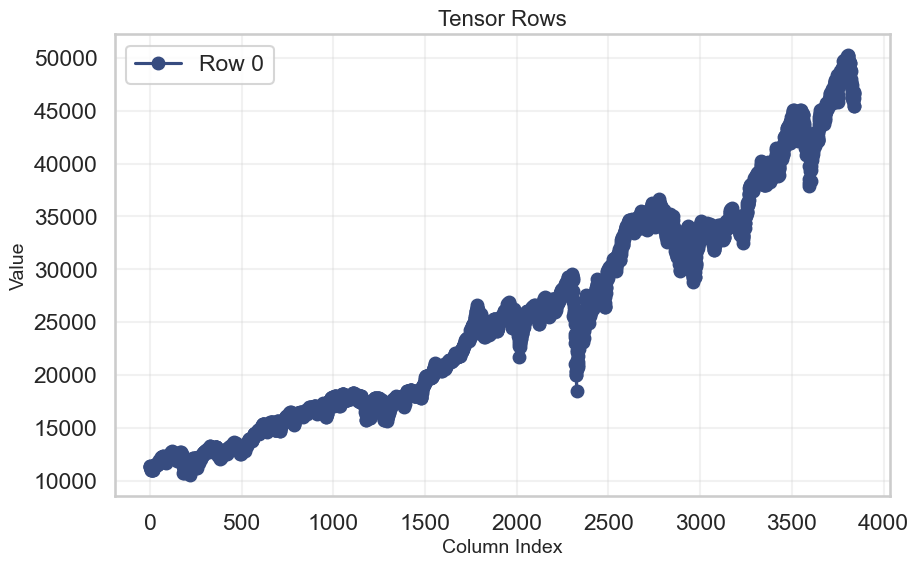

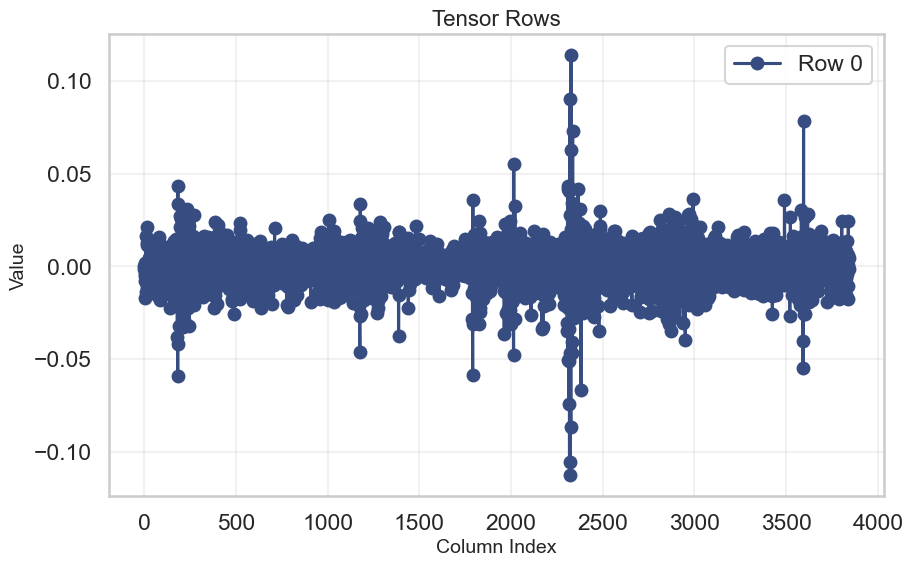

In [55]:
plot_tensor_rows(price_tensor[3])
plot_tensor_rows(return_tensor[3])

In [56]:
#arange, view, and unfold
a = torch.arange(50)
a = a.view(1, -1)
c = a.unfold(1, 20, 1)
print(c)

tensor([[[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
          17, 18, 19],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
          18, 19, 20],
         [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21],
         [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
          20, 21, 22],
         [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
          21, 22, 23],
         [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
          22, 23, 24],
         [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
          23, 24, 25],
         [ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
          24, 25, 26],
         [ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
          25, 26, 27],
         [ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
          26,

In [57]:
#arange, view, and unfold
a = torch.arange(50)
c = a.unfold(0, 20, 1).to(float)
print(c.shape)
d = c.mean(dim=1)
print(d.shape)
#print(c.mean(dim=0))

torch.Size([31, 20])
torch.Size([31])


In [58]:
sma1_period = 20
sma2_period = 60
input_price_tensor = price_tensor[3]
input_return_tensor = return_tensor[3]

print(input_price_tensor.shape)

unfold1 = input_price_tensor.unfold(0, sma1_period, 1).to(float)
unfold2 = input_price_tensor.unfold(0, sma2_period, 1).to(float)

print(unfold1.shape)


torch.Size([3842])
torch.Size([3823, 20])


In [59]:
sma1 = unfold1.mean(dim=1)
sma2 = unfold2.mean(dim=1)
print(sma1.shape)

torch.Size([3823])


In [60]:
sma1_pad = F.pad(sma1, (sma1_period-1, 0))
sma2_pad = F.pad(sma2, (sma2_period-1, 0))
print(sma1_pad.shape)
print(sma2_pad.shape)

torch.Size([3842])
torch.Size([3842])


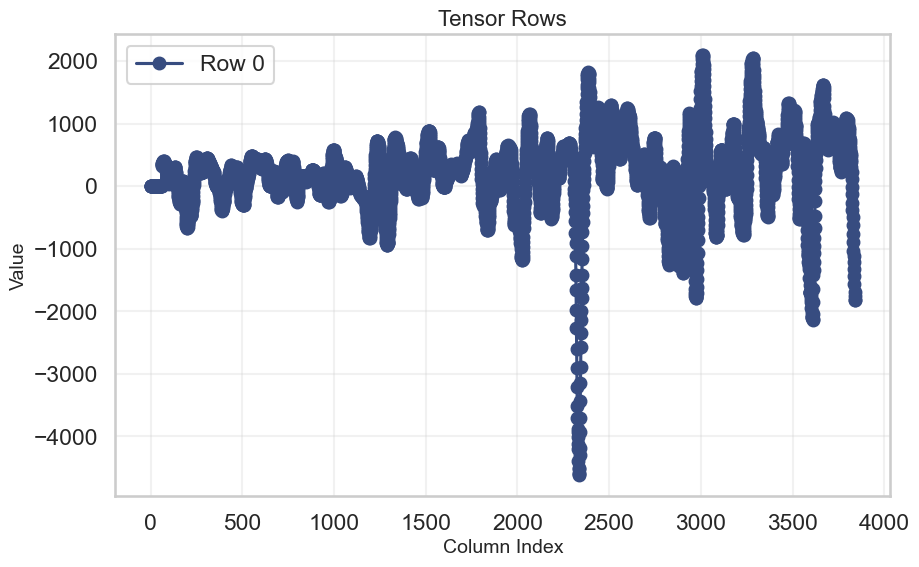

In [61]:
sma_difference = sma1_pad - sma2_pad
sma_difference[:sma2_period+1] = 0
plot_tensor_rows(sma_difference)

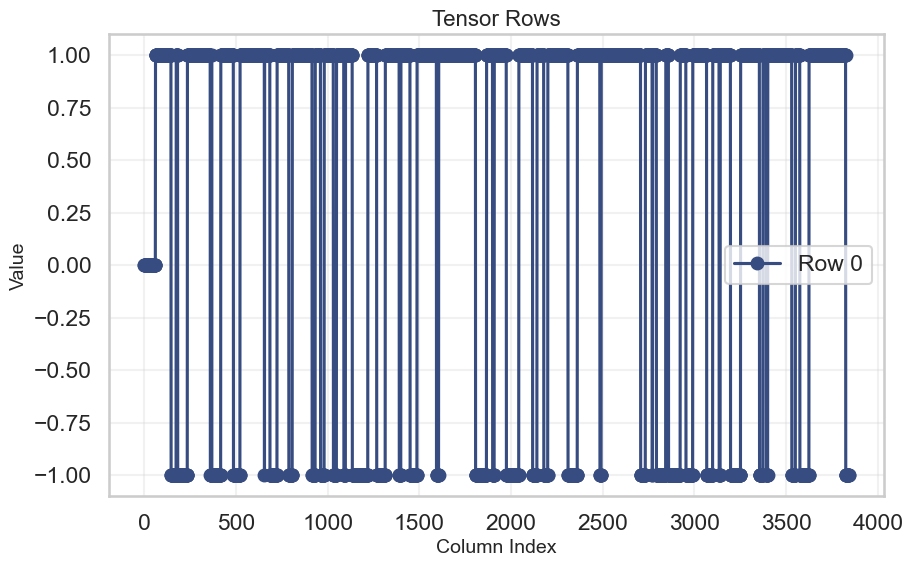

In [ ]:
#return at at time t+1 is the return you'd get from holding asset from time t to t+1
#so using price data from time t, you can calculate your intended position from t to t+1.
#so, based on information at time t, you make a position in time t+1 to capture the return at t+1

positions = torch.sign(sma_difference).roll(1) #this line shifts everything to the right by 1, but also shifts the first
#value into the first position. This is because the position tensor is calculated based on information at time t, but need
#to shift it to get the causality correct. info at time t can't be used for capturing return at time t
positions[0] = 0 #mask out the first value because it would've been the last one.
plot_tensor_rows(positions)

In [63]:
strat_rets = positions * input_return_tensor
print(strat_rets)

tensor([ 0.0000, -0.0000, -0.0000,  ..., -0.0246, -0.0048,  0.0016],
       dtype=torch.float64)


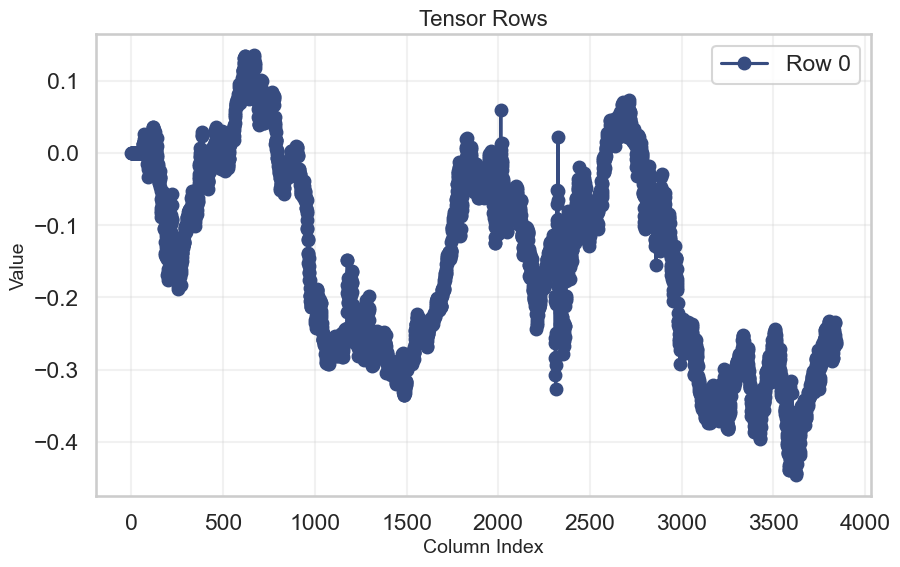

In [64]:
cumulative_rets = strat_rets.cumsum(dim=0)
plot_tensor_rows(cumulative_rets)

In [ ]:
sharpe = strat_rets.mean() / strat_rets.std() * torch.sqrt(torch.tensor(252)) #multiply by sqrt(252) in order to annualize the sharpe
print(sharpe)

tensor(-0.1048, dtype=torch.float64)
